In [1]:
import numpy as np
import matplotlib.pyplot as plt
from solvers.background import solve_tov, eos, real_eos
from scipy.interpolate import interp1d
from IPython.display import display, Markdown
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
#Load Newtonian Data
data = np.load("newtonian.npz")

x_newt = data['x']
rho_newt = data['rho_hat']
P_newt = data['P_hat']

In [3]:
Pc = 1e-4 #Θα το δικαιλογησω απο geometrized units
gamma=2
R_tov, M_tov,Phi_tov_offset, sol = solve_tov(Pc, EoS=eos)
display(Markdown(rf"Η ακτίνα του άστρου είναι **{R_tov:.3f}** km"))
display(Markdown(rf"Η μάζα του άστρου είναι **{M_tov/1.4766:.3f}** $M_\odot$"))

r = np.linspace(1e-3,R_tov,200)
m = sol.sol(r)[0]
P_0 = sol.sol(r)[1]
Phi = sol.sol(r)[2]
rho_0 = eos(P_0)

L_0 = (-1/2)*np.log(1-(2*m/r)) #Lambda
Phi_0 = Phi + Phi_tov_offset



/home/vaggelis/Desktop/Πτυχιακη/Kwdikas/solvers/background.py:95: RuntimeWarning: invalid value encountered in scalar power
  return (P/K)**(1/G) + P/(G-1)


Η ακτίνα του άστρου είναι **10.046** km

Η μάζα του άστρου είναι **0.860** $M_\odot$

In [4]:
def get_dimensionless(M,R,Phi_offset,sol):

    r = np.linspace(1e-2,R,100)
    m = sol.sol(r)[0]
    P = sol.sol(r)[1]
    Phi = sol.sol(r)[2]
    rho = eos(P)

    L_0 = (-1/2)*np.log(1-(2*m/r)) #Lambda
    Phi_0 = Phi + Phi_offset
    #Dimensionless
    x = r/R 
    rho_hat = ((4/3)*np.pi * R**3)/(M)*rho
    P_hat = (4*np.pi*R**4)/(M**2)* P
    m_hat = m/M

    return x,rho_hat,P_hat,m_hat,Phi_0,L_0



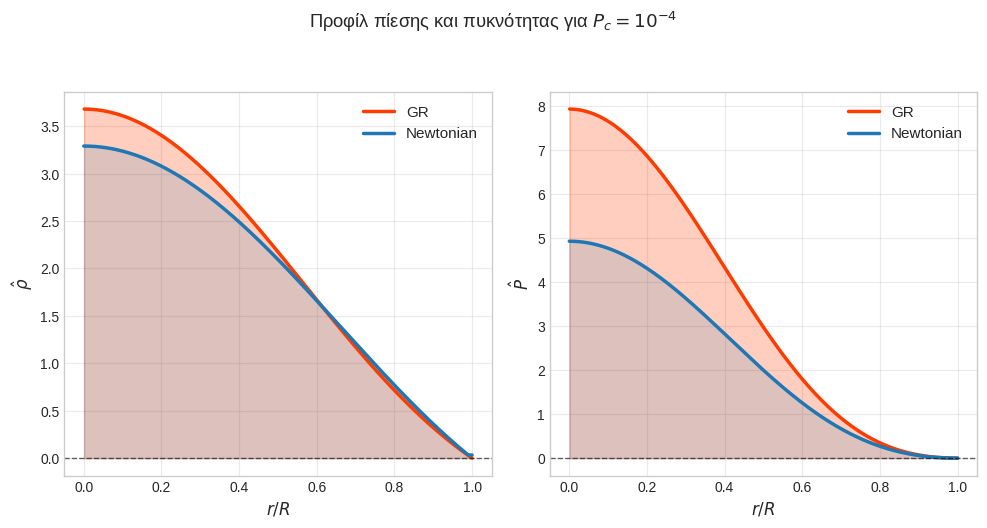

In [5]:
x, rho_tov, P_tov, m_tov, phi_tov,l_tov = get_dimensionless(M_tov, R_tov,Phi_tov_offset,sol)

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

fig, axes = plt.subplots(1,2, figsize=(10, 5))
quantities = {
    r"$\hat{\rho}$": (rho_tov, rho_newt),
    r"$\hat{P}$": (P_tov,P_newt)
}
gr_color = "#ff3c00ff" 
newt_color = '#1f77b4' 
for ax, (label, (qty_tov, qty_newt)) in zip(axes.flatten(), quantities.items()):
    
    ax.plot(x, qty_tov, linewidth=2.5, color=gr_color, label="GR")
    ax.plot(x_newt, qty_newt, linewidth=2.5, color=newt_color, label="Newtonian")
   
    ax.fill_between(x, qty_tov, 0, color=gr_color, alpha=0.25)
    ax.fill_between(x_newt, qty_newt, 0, color=newt_color, alpha=0.15)
    
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
    
    ax.set_xlabel(r'$r/R$')
    ax.set_ylabel(label)
    ax.legend()
    
    ax.grid(True, alpha=0.4, linestyle='-')
fig.suptitle(r"Προφίλ πίεσης και πυκνότητας για $P_c = 10^{-4}$", y=1.05)

plt.tight_layout()
plt.savefig('background_TOV(Γ=2).png', bbox_inches='tight')
plt.show()

In [6]:
#M-R diagram for Γ=2

Pc_values = np.logspace(-5,-1,100)
rho_c_values = eos(Pc_values)
M_list = []
R_list = []

for Pc in Pc_values:
    R,M,Phi,sol = solve_tov(Pc,EoS=eos)
    Msolar = M/1.4766
    M_list.append(Msolar)
    R_list.append(R)


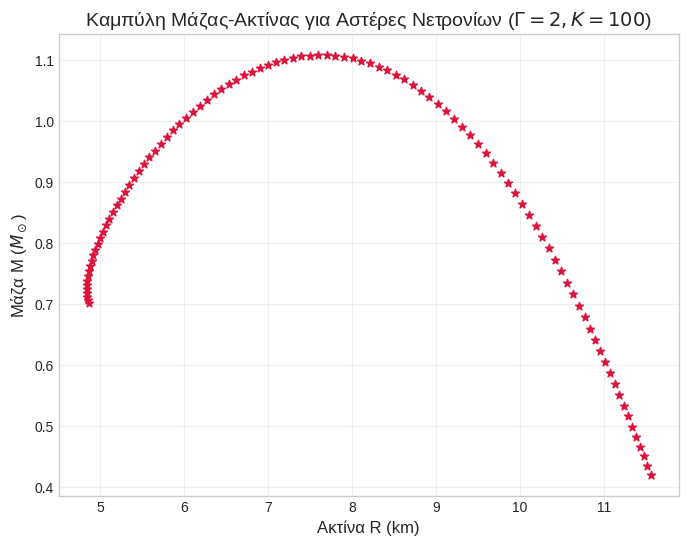

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(R_list, M_list, marker='*', color='crimson')
plt.xlabel('Ακτίνα R (km)', fontsize=12)
plt.ylabel(r'Μάζα M ($M_\odot$)', fontsize=12)
plt.title(r'Καμπύλη Μάζας-Ακτίνας για Αστέρες Νετρονίων ($\Gamma=2, K=100$)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig("M-R_g=2.png")
plt.show()

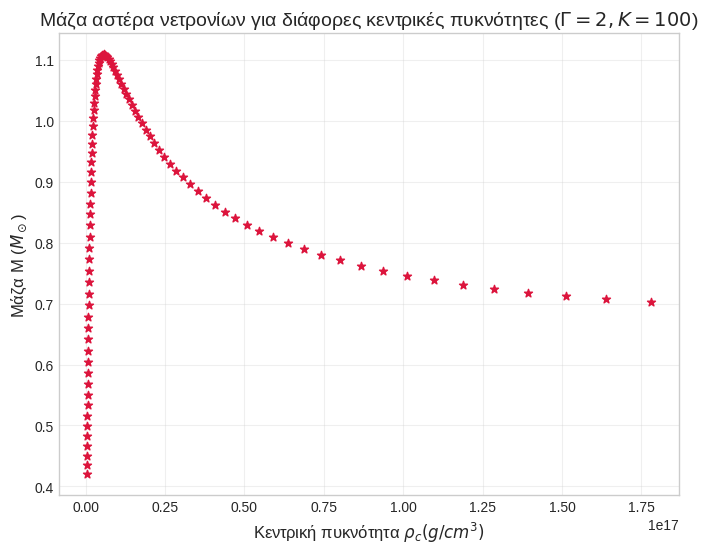

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(rho_c_values/(7.4*1e-19), M_list, marker='*', color='crimson')
plt.xlabel(r'Κεντρική πυκνότητα $\rho_c (g/cm^3)$', fontsize=12)
plt.ylabel(r'Μάζα M ($M_\odot$)', fontsize=12)
plt.title(r'Μάζα αστέρα νετρονίων για διάφορες κεντρικές πυκνότητες ($\Gamma=2, K=100$)', fontsize=14)

plt.grid(True, alpha=0.3)
plt.savefig("rhoc-M_g=2.png")
plt.show()

In [9]:
#Κρίσιμη πυκνότητα, εκει που η μάζα γινεται μεγιστη. 
rho_crit = rho_c_values[np.argmax(M_list)]
display(Markdown(rf"Η κρίσιμη πυκνότητα αυτού του μοντέλου είναι **{rho_crit/(7.4*1e-19):.2e}** $g/cm^3$"))

Η κρίσιμη πυκνότητα αυτού του μοντέλου είναι **5.79e+15** $g/cm^3$

In [10]:
#Ορίζω τις P,W,Q συναρτήσεις, με βάση το μοντέλο ισσοροπίας που έχω (πολυτροπο Γ=2)
P = (gamma*P_0/r**2)*np.exp(L_0+3*Phi_0)
W = ((rho_0+P_0)/r**2)*np.exp(3*L_0 + Phi_0)
dPhi_dr = (-1/(2*r))*(1-np.exp(2*L_0)) + 4*np.pi * r * P_0 * np.exp(2*L_0)
Q = (np.exp(L_0+3*Phi_0))/(r**2)*(rho_0 + P_0)*((dPhi_dr**2) + (4/r)*dPhi_dr -8*np.pi*np.exp(2*L_0)*P_0)


In [17]:
from solvers.shooting_gr import solve_system,get_mode 

c = 299792.458

omega_scan = np.linspace(0.001,0.01,20)
margin = 1e-3
for w2 in omega_scan:
    try:
        residual, _ = solve_system(r,P_fun=P,W_fun=W,Q_fun=Q,omega2=w2)
        if (residual-margin)*(residual+margin) < 0: 
            print(f"Βρέθηκε υποψήφια ιδιοσυχνότητα κοντά στο: {w2}")
            break
    except Exception as e:
        print(f"Σφάλμα στο w2={w2}: {e}")
        break

Βρέθηκε υποψήφια ιδιοσυχνότητα κοντά στο: 0.0019473684210526317


In [18]:
from solvers.shooting_gr import solve_system,get_mode 

c = 299792.458
eig_freq = get_mode(0.001,0.003,r,P,W,Q)
#Σε μονάδες kHz 
fHz = (np.sqrt(eig_freq)*c)/(1000*2*np.pi)
display(Markdown(rf"Η συχνότητα του πρώτου f-mode για $\rho_c = $ **{eos(P_0[0])/(7.4*1e-19):2e}** $g/cm^3$ είναι **{fHz:.3f}** $kHz$"))

Η συχνότητα του πρώτου f-mode για $\rho_c = $ **1.486486e+15** $g/cm^3$ είναι **2.131** $kHz$

In [ ]:
#Ρεαλιστική EoS όπως στο paper των OV
t = np.linspace(1e-5,5,1000)
rho_real, P_real = real_eos(t)

eos_real = interp1d(P_real,rho_real, kind="cubic", fill_value="extrapolate")


In [9]:
Pc=1e-3
R_real,M_real,Phi_real,sol_real = solve_tov(Pc,eos_real)
display(Markdown(rf"Η ακτίνα του άστρου είναι **{R_real:.2f}** km"))
display(Markdown(rf"Η μάζα του άστρου είναι **{M_real/1.4766:.2f}** $M_\odot$"))

Η ακτίνα του άστρου είναι **7.42** km

Η μάζα του άστρου είναι **0.68** $M_\odot$

In [10]:
#M-R diagram for real EoS

Pc_values = np.logspace(-5,-1,50)
M_list = []
R_list = []

for Pc in Pc_values:
    R,M,Phi,sol = solve_tov(Pc,EoS=eos_real)
    Msolar = M/1.4766
    M_list.append(Msolar)
    R_list.append(R)


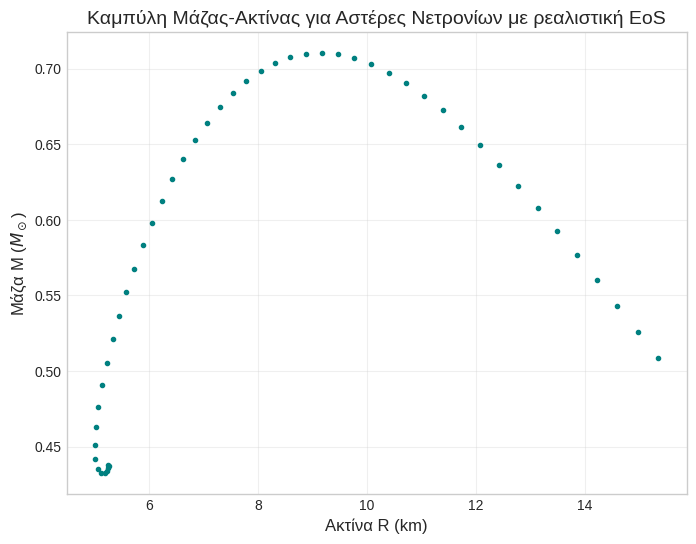

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(R_list, M_list, marker='.', color='teal')
plt.xlabel('Ακτίνα R (km)', fontsize=12)
plt.ylabel(r'Μάζα M ($M_\odot$)', fontsize=12)
plt.title(r'Καμπύλη Μάζας-Ακτίνας για Αστέρες Νετρονίων με ρεαλιστική EoS', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig("M-R_real.png")
plt.show()